### Dataset download ###

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import glob
import tarfile
from pathlib import Path
import cv2
from matplotlib import pyplot as plt
from dotenv import load_dotenv

# Appearance of the Notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Import this module with autoreload
%load_ext autoreload
%autoreload 2

import computervision as cv
from computervision.fileutils import FileOP
from computervision.imageproc import ImageData, is_image
from computervision.imageproc import plot_boxes, enclosing_box, xyxy2xywh, clipxywh, crop_image
from computervision.performance import DetectionMetrics

# Print version info
print(f'Package version: {cv.__version__}')
print(f'Authors:         {cv.__authors__}')
print(f'Python version:  {sys.version}')

Package version: 0.0.1
Authors:         The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.13 (main, Apr 16 2026, 08:53:58) [GCC 13.3.0]


Full data set: https://universe.roboflow.com/shauns-flow/dental-aq0l2

pre-processed: https://dsets.s3.us-east-1.amazonaws.com/classification_datasets/dataset_dental_roboflow.tar.gz

In [2]:
# Load environmental variables
load_dotenv()
data_root = os.environ.get('DATA_DIR')
if data_root is None:
    print('Edit the "env"file and copy it to the root of the repository.') 
    raise FileNotFoundError('No .env file found. The data directory was not set.')

# Directory to store the data
dataset_name = 'classification'
data_dir = os.path.join(data_root, dataset_name)
example_dir = os.path.join(data_dir, 'examples')

# URL with the data set for manual download
url = os.environ.get('CL_URL')
image_dir_name = os.path.basename(url).split('.')[0]
image_dir = os.path.join(data_dir, image_dir_name)

# Verify the image data on disk
file_list = glob.glob(os.path.join(image_dir, '*.jpg'))
assert len(file_list)==995, f'Expected 995 images, found {len(file_list)}. Run first notebook or download the images.'

### Load the annotation file ###

In [3]:
# Open the annotation file (in the image directory after extraction)
annotations_file_name = 'annotations.parquet'
annotations_file = os.path.join(image_dir, annotations_file_name)
df = pd.read_parquet(annotations_file)
display(df.head(2))
print(df.shape)

file_col = 'multi_file'
bbox_col= 'bbox'
disease_col = 'disease'
pos_col = 'pos'
label_col = 'label'

# Chceck the images
file_list = [os.path.join(image_dir, file_name) for file_name in df[file_col].unique()]
checked = [is_image(file) for file in file_list]
assert len(file_list) == sum(checked), f'WARNING: Could not open all {len(file_list)} images at: {image_dir}'
print(f'Image directory:        {image_dir}')
print(f'Total number of images: {len(file_list)}')
print(f'Annotations:            {df.shape[0]}')

,id,license,file_name,height,width,date_captured,file_name_hash,dset,multi_file,bbox,category,disease,pos,box_id
0,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[381.0, 242.0, 481.474, 279.948]",composite,composite,NaN,40762886f4_0
1,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[8.0, 0.0, 130.293, 176.736]",tooth 23,teeth,11.0,40762886f4_1


(12559, 14)
Image directory:        /home/andreas/data/cv_data/classification/dataset_dental_roboflow
Total number of images: 993
Annotations:            12559


### Create the classification data set ###

In [4]:
# Output directory 
output_dir = os.path.join(image_dir, 'cropped')
Path(output_dir).mkdir(exist_ok=True, parents=True)

# Filter very narrow bounding boxes from the edges of the image
min_width = 100

# Small helper function
def crop_bbox(bbox, xmin, ymin):
    return [bbox[0] - xmin, bbox[1] - ymin, bbox[2], bbox[3]]

In [5]:
# Store the labels and bounding boxes in a list
crop_df_list = []

for f, file in enumerate(file_list):

    if (f + 1) % 100 == 0:
        print(f'Processing image {f + 1} / {len(file_list)}')

    file_name = os.path.basename(file)
    df_file = df.loc[df[file_col] == file_name].\
        reset_index(drop=True)
    
    # Load the image
    im = ImageData().load_image(file)
    xlim, ylim = (0, im.shape[1]), (0, im.shape[0])
    
    # Labels and bounding boxes for positions
    df_file_position = df_file.loc[~df_file[pos_col].isnull()]
    pos_labels = np.int64(df_file_position[pos_col].tolist())
    pos_bboxes = df_file_position[bbox_col].tolist()
    pos_bboxes = [clipxywh(list(bbox), xlim=xlim, ylim=ylim) for bbox in pos_bboxes]
    pos_bbox_dict = dict(zip(pos_labels, pos_bboxes))
    
    # Labels and bounding boxes for diseases
    # We need to convert the disease bbox from the xyxy -> xywh format
    df_file_disease = df_file.loc[(df_file[pos_col].isnull())]
    disease_labels = df_file_disease[disease_col].tolist()
    disase_labels_show = [f'{d}:{disease}' for d, disease in enumerate(disease_labels)]
    disease_bboxes = df_file_disease[bbox_col].tolist()
    disease_bboxes = [clipxywh(xyxy2xywh(list(bbox)), xlim=xlim, ylim=ylim) for bbox in disease_bboxes]

    # Loop over the disease labels for this image
    disease_pos_list = []
    for dix, disease_label in enumerate(disease_labels):
    
        disease_bbox = disease_bboxes[dix]
        
        # Calculate the overlap with the tooth bounding boxes
        iou_list = [DetectionMetrics.\
            compute_iou(bbox_1=disease_bbox, bbox_2=bbox, method='np') for bbox in pos_bboxes]
        
        pos_idx_list = [pos_idx for pos_idx in range(len(pos_bboxes)) if iou_list[pos_idx] > 0]
        
        if len(pos_idx_list) > 0:
        
            iou_pos_bboxes = [pos_bboxes[pos_idx] for pos_idx in pos_idx_list]
            
            # Create one bounding box with the teeth affected by the disease
            enclosed_disease_bbox = enclosing_box(bbox_list_xywh=iou_pos_bboxes, offset=20)
            enclosed_disease_bbox = clipxywh(enclosed_disease_bbox, xlim=xlim, ylim=ylim)

            # Filter very narrow bounding boxes from the edges
            if enclosed_disease_bbox[2] >= min_width:
            
                # Crop the image by the size of the larger bounging box
                im_cropped = crop_image(image=im, box=enclosed_disease_bbox)
                xmin = enclosed_disease_bbox[0]
                ymin = enclosed_disease_bbox[1]
                
                # Adjust the bounding box coordinates to the new image size
                disease_bbox_cropped = crop_bbox(disease_bbox, xmin=xmin, ymin=ymin)
                iou_pos_bboxes_cropped = [crop_bbox(bbox, xmin=xmin, ymin=ymin) for bbox in iou_pos_bboxes]
                iou_pos_labels = [pos_labels[pos_idx] for pos_idx in pos_idx_list]
                disease_pos_list.extend(iou_pos_labels)
            
                # Save the cropped image
                im_cropped_name = f'{disease_label}_{str(dix).zfill(2)}_{file_name}'
                im_cropped_file = os.path.join(output_dir, im_cropped_name)
                cv2.imwrite(im_cropped_file, cv2.cvtColor(im_cropped, cv2.COLOR_RGB2BGR))    
                
                # Save the bounding box and other data
                crop_dict = {file_col: file_name,
                             'file_name': im_cropped_name,
                             'width': im_cropped.shape[1],
                             'height': im_cropped.shape[0],
                             'area': im_cropped.shape[0] * im_cropped.shape[1], 
                             label_col: disease_label,
                             bbox_col: [disease_bbox_cropped],
                             pos_col: [iou_pos_labels],
                             'pos_bbox': [iou_pos_bboxes_cropped]}
                
                crop_df_list.append(pd.DataFrame(crop_dict, index=[dix]))
    
    # Fix the healthy teeth that do not have a disease label
    tooth_list = list(sorted(set(pos_labels).difference(disease_pos_list)))
    disease_label = 'tooth'

    if len(tooth_list) > 0:

        for p, pos in enumerate(tooth_list):
            pos_bbox = pos_bbox_dict.get(pos)
            
            # Avoid very narrow images from the edges
            if pos_bbox[2] >= min_width:
            
                im_cropped = crop_image(image=im, box=pos_bbox)
                im_cropped_name = f'{disease_label}_{str(pos).zfill(2)}_{file_name}'
                im_cropped_file = os.path.join(output_dir, im_cropped_name)
                cv2.imwrite(im_cropped_file, cv2.cvtColor(im_cropped, cv2.COLOR_RGB2BGR))
                
                # Save the bounding box and other data
                crop_dict = {file_col: file_name,
                             'file_name': im_cropped_name,
                             'width': im_cropped.shape[1],
                             'height': im_cropped.shape[0],
                             'area': im_cropped.shape[0] * im_cropped.shape[1], 
                             label_col: disease_label,
                             bbox_col: np.nan,
                             pos_col: [[pos]],
                             'pos_bbox': np.nan}
                        
                crop_df_list.append(pd.DataFrame(crop_dict, index=[p]))

# Assemble the final data frame and save it
crop_df_file_name = f'{os.path.splitext(annotations_file_name)[0]}_cropped.parquet'
crop_df_file = os.path.join(output_dir, crop_df_file_name)
crop_df = pd.concat(crop_df_list, axis=0, ignore_index=True)

print(f'Saving annotations to file: {crop_df_file}')
crop_df.to_parquet(crop_df_file)

cropped_file_list = [os.path.join(output_dir, file_name) for file_name in crop_df['file_name'].unique()]
checked = [is_image(file) for file in cropped_file_list]
assert sum(checked) == len(cropped_file_list)
print(f'Number of created in        {output_dir}: {len(cropped_file_list)}')
print(crop_df.shape)
display(crop_df.head())

Processing image 100 / 993
Processing image 200 / 993
Processing image 300 / 993
Processing image 400 / 993
Processing image 500 / 993
Processing image 600 / 993
Processing image 700 / 993
Processing image 800 / 993
Processing image 900 / 993
Saving annotations to file: /home/andreas/data/cv_data/classification/dataset_dental_roboflow/cropped/annotations_cropped.parquet
Number of created in        /home/andreas/data/cv_data/classification/dataset_dental_roboflow/cropped: 7697
(7697, 9)


,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox
0,40762886f4.jpg,composite_00_40762886f4.jpg,455,277,126035,composite,"[196, 39, 100, 37]","[20, 19]","[[20, 20, 338, 257], [144, 23, 311, 254]]"
1,40762886f4.jpg,tooth_11_40762886f4.jpg,130,176,22880,tooth,NaN,[11],NaN
2,40762886f4.jpg,tooth_13_40762886f4.jpg,258,186,47988,tooth,NaN,[13],NaN
3,40762886f4.jpg,tooth_14_40762886f4.jpg,382,192,73344,tooth,NaN,[14],NaN
4,40762886f4.jpg,tooth_15_40762886f4.jpg,204,185,37740,tooth,NaN,[15],NaN


### Check the data ###

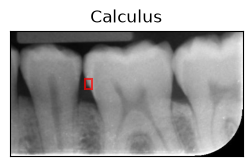

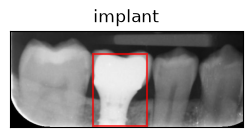

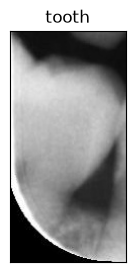

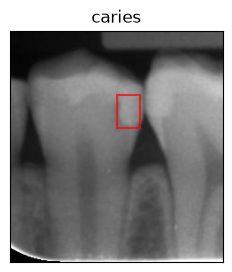

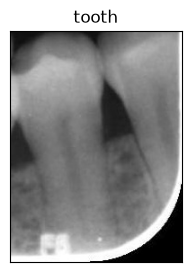

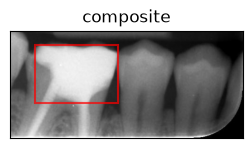

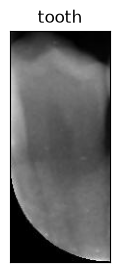

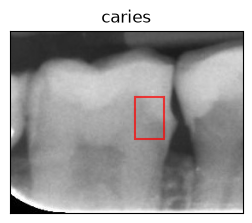

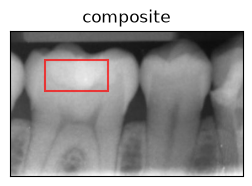

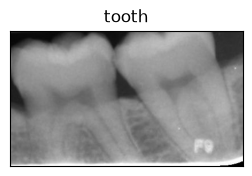

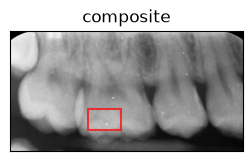

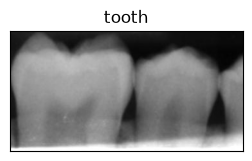

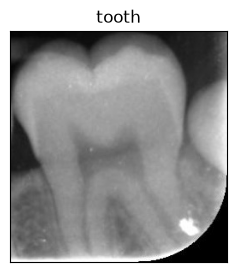

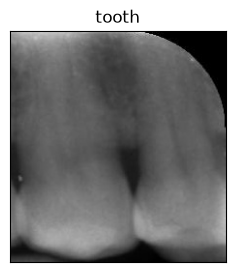

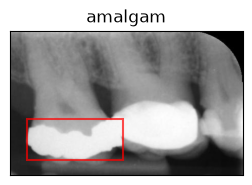

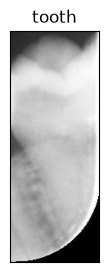

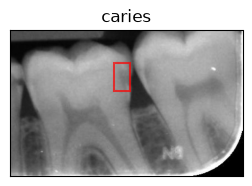

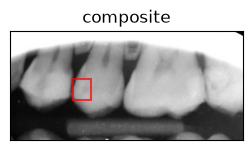

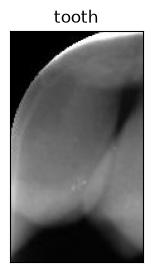

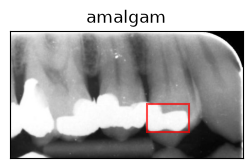

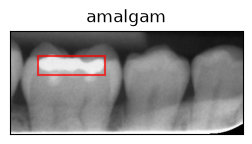

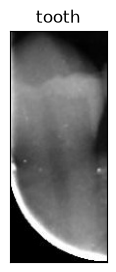

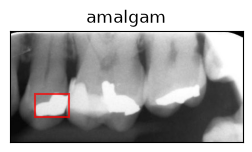

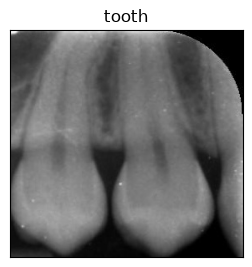

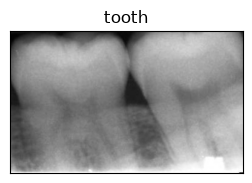

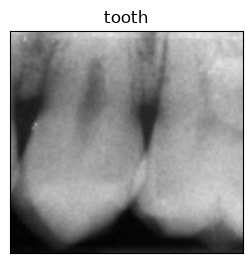

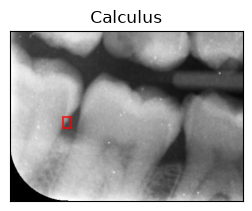

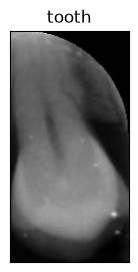

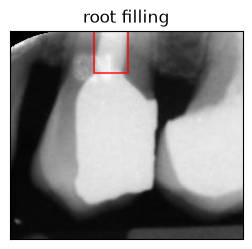

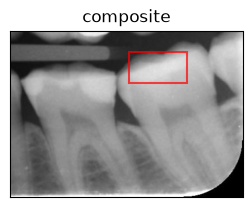

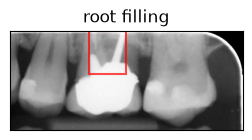

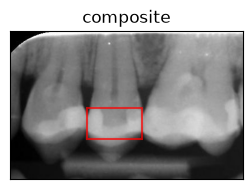

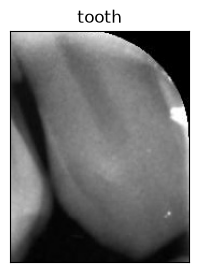

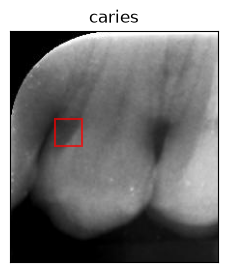

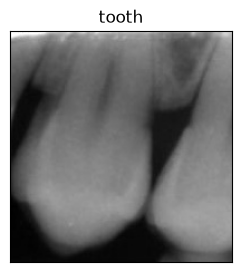

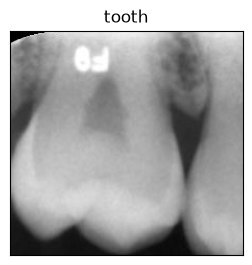

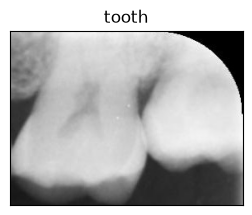

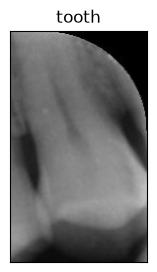

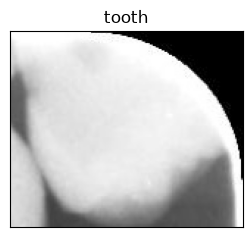

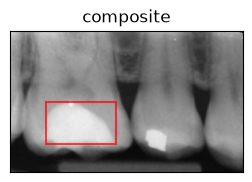

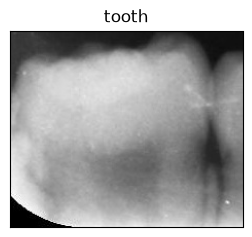

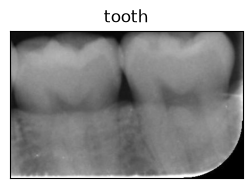

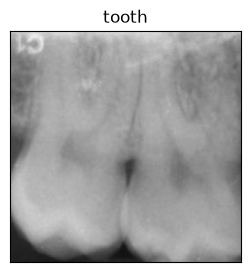

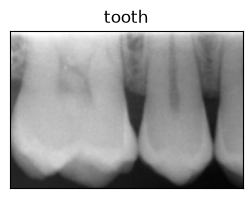

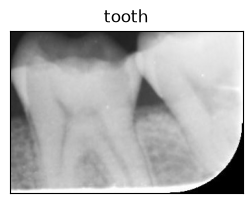

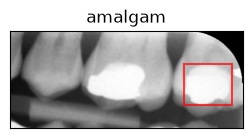

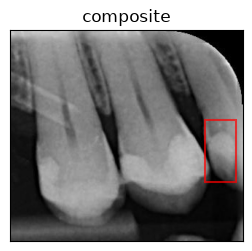

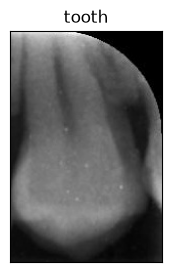

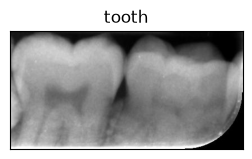

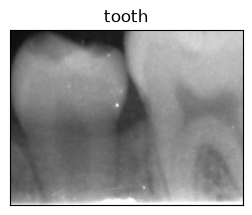

In [6]:
crop_df = pd.read_parquet(crop_df_file)
file_name_list = crop_df['file_name'].unique()
seed = 234
rng = np.random.default_rng(seed)

# Pick a few random files
n_files = 50
file_names = rng.choice(file_name_list, size=n_files, replace=False)

for f, file_name in enumerate(file_names):
    file = os.path.join(output_dir, file_name)
    im = ImageData().load_image(file)
    label = crop_df.loc[crop_df['file_name'] == file_name, 'label'].tolist()[0]
    bbox = crop_df.loc[crop_df['file_name'] == file_name, 'bbox'].tolist()[0]
    fig, ax = plt.subplots(figsize=(3, 3))
    if bbox is None:
        ax.imshow(im)
        ax.set(xticks=[], yticks=[])
    else:
        ax = plot_boxes(image=im, box_list=[bbox], color='r', ax=ax)
    ax.set(title=label)
    
    # Before we show the image, we save it to the exampled directory
    output_file_name = f'{os.path.splitext(file_name)[0]}_cropped.png'
    output_file = os.path.join(example_dir, output_file_name)
    plt.savefig(output_file, bbox_inches='tight', transparent=True)
    plt.show()